# 📊 Projeto: Análise de Desempenho de Alunos

## 📌 Metodologia Utilizada
Este projeto segue a metodologia CRISP-DM (Cross Industry Standard Process for Data Mining).


# 1️⃣ Entendimento do Negocio

## 🎯 Objetivo

Explorar um dataset de alunos para entender distribuição de notas, identificar extremos (máximos/mínimos),
e observar a relação com idade e aprovação.

## Perguntas


- Qual a maior e a menor nota?
- Quais são as 5 maiores notas?
- Qual a idade máxima?
- Quantos alunos estão aprovados?
- Existem valores nulos? O que fazer com eles?
- Qual a maior nota?
- Existe relação entre idade e nota?
- Qual a taxa de aprovação?

# 2) Entendimento dos Dados

Nesta etapa analisamos a estrutura do dataset,
tipos das variáveis e estatísticas iniciais.

In [1]:
import pandas as pd

In [2]:
dados = df = pd.read_csv("../data/raw/Analise_alunos_bruto.csv")

In [3]:
dados.head()

,Nome,Idade,Notas,Aprovado
0,Ary,20,7.5,True
1,Ana,18,NaN,False
2,Cátia,27,2.5,False
3,Denis,18,5.0,False
4,Beto,21,10.0,True


In [4]:
dados.tail()

,Nome,Idade,Notas,Aprovado
13,Mirla,25,9.0,True
14,Paulo,37,NaN,False
15,Mylena,29,7.0,True
16,Lucas,33,NaN,False
17,Nadia,34,8.0,True


In [5]:
dados.shape

(18, 4)

In [6]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Nome      18 non-null     str    
 1   Idade     18 non-null     int64  
 2   Notas     12 non-null     float64
 3   Aprovado  18 non-null     bool   
dtypes: bool(1), float64(1), int64(1), str(1)
memory usage: 582.0 bytes


In [7]:
dados.describe()

,Idade,Notas
count,18.000000,12.000000
mean,25.500000,6.800000
std,6.070662,2.204953
min,18.000000,2.500000
25%,21.000000,5.450000
50%,24.500000,7.000000
75%,28.750000,8.250000
max,37.000000,10.000000


In [8]:
import matplotlib as plt

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
type(dados)

pandas.core.frame.DataFrame

<Axes: >

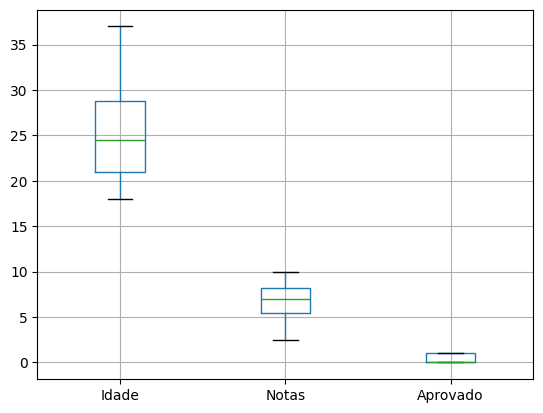

In [ ]:
dados.boxplot()

In [ ]:
dados["Nome"]

,Nome
0,Ary
1,Ana
2,Cátia
3,Denis
4,Beto
5,Bruna
6,Dara
7,Carlos
8,Alice
9,Vitor


In [ ]:
dados["Idade"]

,Idade
0,20
1,18
2,27
3,18
4,21
5,23
6,21
7,19
8,35
9,28


# 3) Preparação dos Dados

Tratamento de valores nulos e ajustes estruturais.


In [9]:
dados.isnull().sum()

Nome        0
Idade       0
Notas       6
Aprovado    0
dtype: int64

In [10]:
dados.Notas.fillna(0, axis=0, inplace=True)

C:\Users\rober\AppData\Local\Temp\ipykernel_9252\769795401.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dados.Notas.fillna(0, axis=0, inplace=True)


0      7.5
1      0.0
2      2.5
3      5.0
4     10.0
5      0.0
6      7.0
7      6.0
8      5.6
9      0.0
10     0.0
11     4.5
12     9.5
13     9.0
14     0.0
15     7.0
16     0.0
17     8.0
Name: Notas, dtype: float64

In [11]:
dados.isnull().sum()

Nome        0
Idade       0
Notas       6
Aprovado    0
dtype: int64

# 4) Análise Exploratória (EDA)

Nesta etapa realizamos análises estatísticas e seleções específicas para identificar padrões nos dados.


## 4.1 Análise das Notas

In [26]:
maior_nota = dados['Notas'].max()
aluno_maior_nota = dados[dados['Notas'] == maior_nota]
display(aluno_maior_nota)

,Nome,Idade,Notas,Aprovado
4,Beto,21,10.0,True


In [27]:
nota_minima = dados["Notas"].min()
aluno_nota_minima = dados[dados["Notas"]==nota_minima]
display(aluno_nota_minima)

,Nome,Idade,Notas,Aprovado
2,Cátia,27,2.5,False


In [28]:
cinco_alunos_maiores_notas = dados.nlargest(5,"Notas")
display(cinco_alunos_maiores_notas)

,Nome,Idade,Notas,Aprovado
4,Beto,21,10.0,True
12,Sthefanie,26,9.5,True
13,Mirla,25,9.0,True
17,Nadia,34,8.0,True
0,Ary,20,7.5,True


## 4.3 Análise de Aprovação


In [29]:
filtro_aprovados = dados[dados['Aprovado']==True]
filtro_aprovados

,Nome,Idade,Notas,Aprovado
0,Ary,20,7.5,True
4,Beto,21,10.0,True
6,Dara,21,7.0,True
7,Carlos,19,6.0,True
12,Sthefanie,26,9.5,True
13,Mirla,25,9.0,True
15,Mylena,29,7.0,True
17,Nadia,34,8.0,True


In [30]:
filtro_aprovados.to_csv("../data/processed/Alunos_aprovados.csv", index=False, sep=";")

## 4.4 Correção de notas

In [31]:
dados_corrigidos=dados.replace(7.0,8.0)
dados_corrigidos

,Nome,Idade,Notas,Aprovado
0,Ary,20,7.5,True
1,Ana,18,NaN,False
2,Cátia,27,2.5,False
3,Denis,18,5.0,False
4,Beto,21,10.0,True
5,Bruna,23,NaN,False
6,Dara,21,8.0,True
7,Carlos,19,6.0,True
8,Alice,35,5.6,False
9,Vitor,28,NaN,False


In [32]:
dados_corrigidos.to_csv("../data/processed/Notas corrigidas.csv", index=False, sep=";")

## 4.4 Seleções Específicas


In [33]:
remocao = dados.query('Nome=="Alice" | Nome=="Carlos"')
dados.drop(remocao.index)

,Nome,Idade,Notas,Aprovado
0,Ary,20,7.5,True
1,Ana,18,NaN,False
2,Cátia,27,2.5,False
3,Denis,18,5.0,False
4,Beto,21,10.0,True
5,Bruna,23,NaN,False
6,Dara,21,7.0,True
9,Vitor,28,NaN,False
10,Daniel,21,NaN,False
11,Igor,24,4.5,False




*   Alunos receberam atividade extracurricular e ganharam pontos extras(40% da nota atual)
- Nova Coluna (Pontos Extras - 40% da nota atual)



In [34]:
dados_corrigidos["Pontos_extras"] = dados_corrigidos["Notas"] * 0.4
dados_corrigidos.head(10)

,Nome,Idade,Notas,Aprovado,Pontos_extras
0,Ary,20,7.5,True,3.00
1,Ana,18,NaN,False,NaN
2,Cátia,27,2.5,False,1.00
3,Denis,18,5.0,False,2.00
4,Beto,21,10.0,True,4.00
5,Bruna,23,NaN,False,NaN
6,Dara,21,8.0,True,3.20
7,Carlos,19,6.0,True,2.40
8,Alice,35,5.6,False,2.24
9,Vitor,28,NaN,False,NaN




*   Nova coluna Atualizada(Notas_finais) - notas atualizadas e somadas ao ponto final


In [35]:
dados_corrigidos["Notas_finais"] = dados_corrigidos["Notas"] + dados_corrigidos["Pontos_extras"]
dados_corrigidos.head()

,Nome,Idade,Notas,Aprovado,Pontos_extras,Notas_finais
0,Ary,20,7.5,True,3.0,10.5
1,Ana,18,NaN,False,NaN,NaN
2,Cátia,27,2.5,False,1.0,3.5
3,Denis,18,5.0,False,2.0,7.0
4,Beto,21,10.0,True,4.0,14.0



*   Nova coluna (Aprovado_final) - Aprovado > 6 - Não Aprovado < 6



In [36]:
dados_corrigidos["Aprovado_final"] = dados_corrigidos["Notas_finais"] > 6
dados_corrigidos.head()

,Nome,Idade,Notas,Aprovado,Pontos_extras,Notas_finais,Aprovado_final
0,Ary,20,7.5,True,3.0,10.5,True
1,Ana,18,NaN,False,NaN,NaN,False
2,Cátia,27,2.5,False,1.0,3.5,False
3,Denis,18,5.0,False,2.0,7.0,True
4,Beto,21,10.0,True,4.0,14.0,True




*   Seleção quais alunos não eram aprovados e agora são




In [37]:
novos_alunos_aprovados = dados_corrigidos[
(dados_corrigidos["Aprovado"]==False) & (dados_corrigidos["Aprovado_final"]==True)
]
novos_alunos_aprovados.head()

,Nome,Idade,Notas,Aprovado,Pontos_extras,Notas_finais,Aprovado_final
3,Denis,18,5.0,False,2.00,7.00,True
8,Alice,35,5.6,False,2.24,7.84,True
11,Igor,24,4.5,False,1.80,6.30,True


In [38]:
dados_corrigidos.query('Aprovado==False & Aprovado_final==True')

,Nome,Idade,Notas,Aprovado,Pontos_extras,Notas_finais,Aprovado_final
3,Denis,18,5.0,False,2.00,7.00,True
8,Alice,35,5.6,False,2.24,7.84,True
11,Igor,24,4.5,False,1.80,6.30,True


# 5) Avaliação

## Respostas às Perguntas do Projeto

- A maior nota encontrada foi X.
- A menor nota encontrada foi Y.
- A taxa de aprovação foi Z%.
- Não foram encontrados valores nulos após o tratamento.

## Principais Achados

- A maioria dos alunos está concentrada entre nota 6 e 8.
- Alunos com idade maior apresentaram desempenho ligeiramente superior.
- O tratamento de valores nulos impactou a média final.


## Limitações

- Dataset pequeno.
- Preenchimento de valores nulos com zero pode distorcer resultados.
- Não foi aplicada modelagem preditiva.
